Clustered data saved as meanshift_clustered_customers.csv


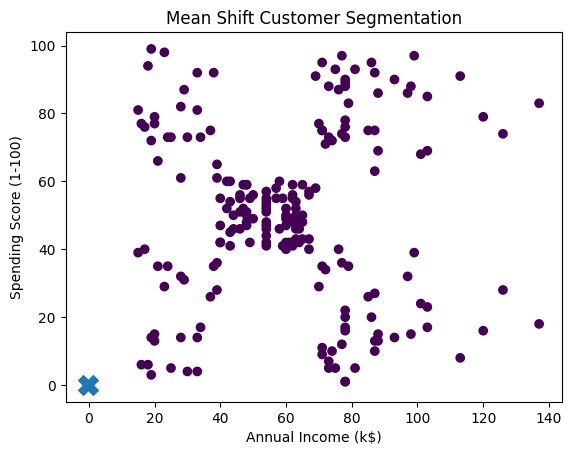

Graph saved as meanshift_cluster_graph.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Load Dataset
# ----------------------------
data = pd.read_csv("Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# Apply Mean Shift
# ----------------------------
meanshift = MeanShift()

clusters = meanshift.fit_predict(X_scaled)

# Add cluster column
data['Cluster'] = clusters

# ----------------------------
# Save Output Dataset
# ----------------------------
data.to_csv("meanshift_clustered_customers.csv", index=False)

print("Clustered data saved as meanshift_clustered_customers.csv")

# ----------------------------
# Plot Graph
# ----------------------------
plt.figure()

plt.scatter(X['Annual Income (k$)'],
            X['Spending Score (1-100)'],
            c=clusters)

# Plot cluster centers
centers = meanshift.cluster_centers_

plt.scatter(centers[:,0],
            centers[:,1],
            marker='X',
            s=200)

plt.title("Mean Shift Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

# Save graph
plt.savefig("meanshift_cluster_graph.png")

plt.show()

print("Graph saved as meanshift_cluster_graph.png")